<a href="https://colab.research.google.com/github/DikshyaL/DL-Practice/blob/main/Comp488_pl7_dikshya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Generative AI – VAE on Fashion‑MNIST  
- **Student name:** Dikshya Lamichhane  
- **Course:** COMP 488 – Neural Network and Deep Learning  
- **Mapped unit:** Unit 5 – Frontiers  
- **Date:** May 16, 2026  
- **Assignment focus:** Variational Autoencoder (VAE)  
- **Dataset:** Fashion‑MNIST  
- **Framework:** PyTorch  

## Objective

- To implement a **Variational Autoencoder (VAE)** using PyTorch on the Fashion‑MNIST dataset.  
- To train the VAE and generate new fashion‑style images from the learned latent space.  
- To visualize the latent space using **PCA** and **t‑SNE** to understand how different classes are organized.  
- To experiment with multiple hyperparameter settings such as:
  - Latent dimension (`latent_dim`),  
  - Hidden layer size (`hidden_dim`),  
  - Learning rate (`lr`),  
  - KL divergence weight (`beta`).  

## Theoretical Background

A **Variational Autoencoder (VAE)** is a generative deep learning model that learns a **probabilistic latent representation** of input data. Unlike a standard autoencoder that maps each input to a single fixed vector, a VAE learns a **distribution over the latent space**, which allows it to generate new realistic samples by sampling from this distribution.

### Encoder

The encoder maps an input image \(x\) into a latent distribution defined by:

- Mean vector: \(\mu\)  
- Log variance vector: \(\log \sigma^2\)

Instead of producing a single encoding, the encoder outputs parameters of a Gaussian distribution:

$$
q(z|x) = \mathcal{N}(\mu, \sigma^2)
$$

This represents uncertainty in the latent space.

### Decoder

The decoder samples a latent vector \(z\) from the learned distribution and reconstructs the input:

$$
\hat{x} = f_{\theta}(z)
$$

The objective is to make \(\hat{x}\) as close as possible to the original input \(x\).

### Reparameterization Trick

Direct sampling blocks gradient flow, so VAEs use the reparameterization trick.

Instead of sampling:

$$
z \sim \mathcal{N}(\mu, \sigma^2)
$$

we rewrite it as:

$$
z = \mu + \sigma \cdot \epsilon
$$

where:

$$
\epsilon \sim \mathcal{N}(0,1)
$$

This allows gradients to flow through \(\mu\) and \(\sigma\).

### Loss Function (ELBO)

The VAE is trained by minimizing the negative Evidence Lower Bound (ELBO), which decomposes into reconstruction loss and KL divergence regularization:
$$
\mathcal{L} = \mathcal{L}_{recon} + \beta \cdot \mathcal{L}_{KL}
$$

### Reconstruction Loss

Measures how well the model reconstructs the input:

$$
\mathcal{L}_{recon} = \text{BCE}(x, \hat{x})
$$

### KL Divergence

Regularizes the latent space to match a standard normal distribution:

$$
\mathcal{L}_{KL} = D_{KL}\big(\mathcal{N}(\mu, \sigma^2) \parallel \mathcal{N}(0,1)\big)
$$

### Role of β (Beta)

- Low β → better reconstruction, weaker structure  
- High β → stronger structure, blurrier outputs  

### Workflow

1. Input image \(x\) → Encoder  
2. Encoder outputs \(\mu, \sigma\)  
3. Sample latent vector:

$$
z = \mu + \sigma \cdot \epsilon
$$

4. Decoder reconstructs \(\hat{x}\)  
5. Optimize reconstruction + KL loss  

### Key Applications

- Image generation  
- Representation learning  
- Dimensionality reduction  
- Probabilistic modeling  


## Dataset Description

The dataset used in this assignment is **Fashion‑MNIST**.

Fashion‑MNIST is a grayscale image dataset consisting of clothing and fashion‑related items. It is commonly used as a benchmark dataset for image classification and generative modeling tasks.

### Dataset Details

- Training samples: **60,000**  
- Test samples: **10,000**  
- Image size: **28 × 28** pixels  
- Image type: Grayscale  
- Number of classes: **10**  

### Fashion‑MNIST Classes

1. T‑shirt/top  
2. Trouser  
3. Pullover  
4. Dress  
5. Coat  
6. Sandal  
7. Shirt  
8. Sneaker  
9. Bag  
10. Ankle boot  

### Preprocessing Steps

- Images are converted into tensors.  
- Pixel values are normalized into the range \([0,1]\).  
- Each image is flattened into a vector of size **784**.

### Train / Test Split

The dataset already provides a standard split:
- Training set: 60,000 images  
- Test set: 10,000 images  

This predefined split is used directly in the implementation.

In [ ]:
!pip install torch torchvision matplotlib scikit-learn tqdm

In [ ]:
# imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# data loading and preprocessing
# Define transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    # Flatten to vector of 784 (28×28) or keep as 1×28×28
    transforms.Lambda(lambda x: x.view(-1))
])

# Load Fashion‑MNIST
train_dataset = datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)

# Create loaders
batch_size = 128
train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=2
)
test_loader  = DataLoader(
    test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2
)

print(f"Train set: {len(train_dataset)} samples")
print(f"Test set:  {len(test_dataset)} samples")

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 182kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.27MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.11MB/s]


Train set: 60000 samples
Test set:  10000 samples


In [ ]:
# Define VAE model
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=256, latent_dim=20):
        super(VAE, self).__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim

        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)

        self.fc_mu   = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, hidden_dim)
        self.fc5 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        h = F.relu(self.fc2(h))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc3(z))
        h = F.relu(self.fc4(h))
        return torch.sigmoid(self.fc5(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

# Build model
latent_dim = 20
model = VAE(latent_dim=latent_dim).to(device)

print(model)

VAE(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (fc_mu): Linear(in_features=256, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=256, out_features=20, bias=True)
  (fc3): Linear(in_features=20, out_features=256, bias=True)
  (fc4): Linear(in_features=256, out_features=256, bias=True)
  (fc5): Linear(in_features=256, out_features=784, bias=True)
)


In [ ]:
# loss function
def vae_loss(x, x_recon, mu, logvar, beta=1.0):
    # Reconstruction loss (binary cross‑entropy)
    # x and x_recon are in [0, 1]
    recon_loss = F.binary_cross_entropy(x_recon, x, reduction="sum")

    # KL divergence (between q(z|x) and p(z))
    # KL = 0.5 * sum(1 + logvar - mu² - exp(logvar))
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl_loss, recon_loss, kl_loss

In [ ]:
# training loop
# Training settings
lr = 1e-3
num_epochs = 10
beta = 1.0  # KL weight

optimizer = optim.Adam(model.parameters(), lr=lr)

train_losses = []
test_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    n_samples = 0

    for x, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        x = x.to(device)  # x shape: [batch, 784]

        optimizer.zero_grad()
        x_recon, mu, logvar = model(x)
        loss, recon, kl = vae_loss(x, x_recon, mu, logvar, beta=beta)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        n_samples += x.size(0)

    avg_train_loss = epoch_loss / n_samples
    train_losses.append(avg_train_loss)
    print(f"Epoch {epoch+1}: Train loss = {avg_train_loss:.4f}")

    # Optional: evaluate on test set
    model.eval()
    with torch.no_grad():
        test_loss = 0.0
        n_test = 0
        for x, _ in test_loader:
            x = x.to(device)
            x_recon, mu, logvar = model(x)
            loss, _, _ = vae_loss(x, x_recon, mu, logvar, beta=beta)
            test_loss += loss.item()
            n_test += x.size(0)
        avg_test_loss = test_loss / n_test
        test_losses.append(avg_test_loss)

print("Training finished.")

Epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1: Train loss = 293.1362


Epoch 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2: Train loss = 255.7304


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78c0ef980cc0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    Exception ignored in: self._shutdown_workers()<function _MultiProcessingDataLoaderIter.__del__ at 0x78c0ef980cc0>

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
Traceback (most recent call last):
    if w.is_alive():  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__

     self._shutdown_workers() 
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
       if w.is_alive(): 
^^  ^ ^^  ^ ^ ^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^^  
   File "/usr/lib/pyt

...

Epoch 8: Train loss = 243.5050


Epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 9: Train loss = 242.8008


Epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 10: Train loss = 242.1880
Training finished.


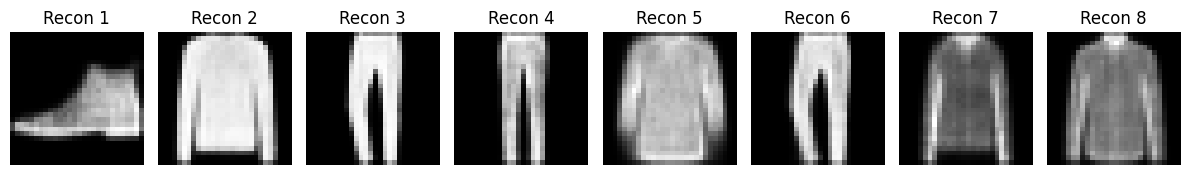

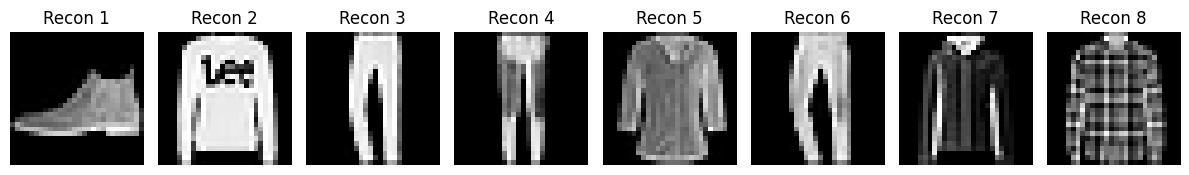

In [ ]:
# reconstruct image and visualize
def show_images(images, titles, n_cols=8, figsize=(12, 4)):
    n_rows = int(np.ceil(len(images) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flat if n_rows > 1 else (axes if isinstance(axes, np.ndarray) else [axes])

    for i in range(len(images)):
        img = images[i].reshape(28, 28)
        axes[i].imshow(img, cmap="gray")
        axes[i].set_title(titles[i])
        axes[i].axis("off")

    for j in range(len(images), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

# Pick a batch from test set
model.eval()
with torch.no_grad():
    x, _ = next(iter(test_loader))
    x = x.to(device)
    x_recon, _, _ = model(x)

    # Take first 8 images
    x_plot = x.cpu().numpy()[:8]
    x_recon_plot = x_recon.cpu().numpy()[:8]

titles = [f"Recon {i+1}" for i in range(8)]
show_images(x_recon_plot, titles)
show_images(x_plot, titles)

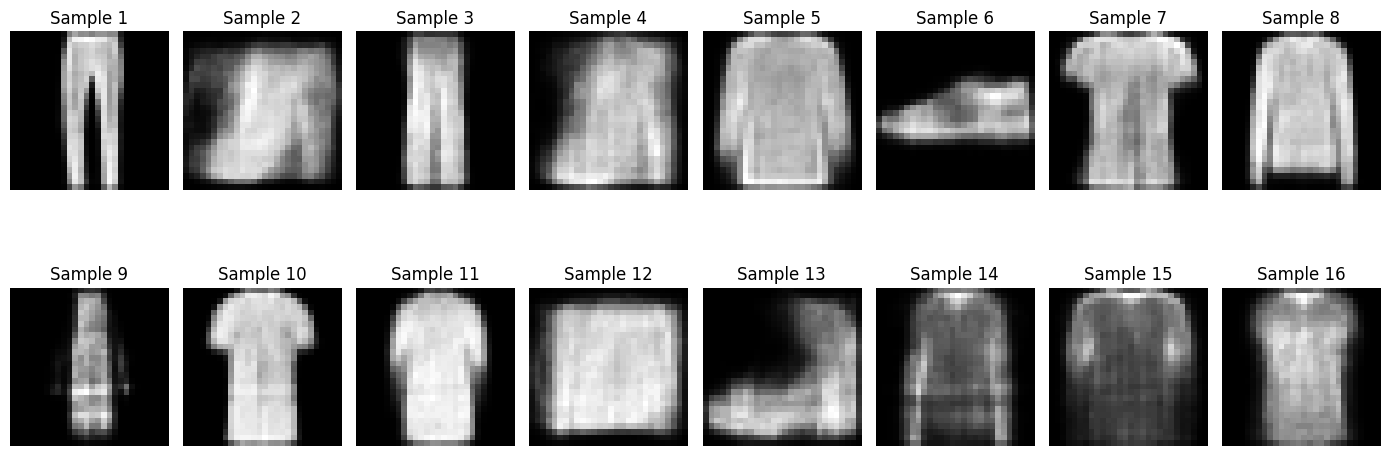

In [ ]:
# Sample from the prior (standard normal) in latent space
n_samples = 16
z_sample = torch.randn(n_samples, latent_dim).to(device)
with torch.no_grad():
    x_gen = model.decode(z_sample).cpu().numpy()

titles = [f"Sample {i+1}" for i in range(n_samples)]
show_images(x_gen, titles, n_cols=8, figsize=(14, 6))

In [ ]:

# Extract latent vectors from test set
model.eval()
all_z = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        mu, logvar = model.encode(x)
        z = model.reparameterize(mu, logvar)  # or just use mu for mean
        all_z.append(z.cpu())
        all_labels.append(y.cpu())

z_all = torch.cat(all_z, dim=0).numpy()   # shape [N_test, latent_dim]
y_all = torch.cat(all_labels, dim=0).numpy()

print(f"Latent vectors shape: {z_all.shape}")
print(f"Labels shape: {y_all.shape}")

Latent vectors shape: (10000, 20)
Labels shape: (10000,)


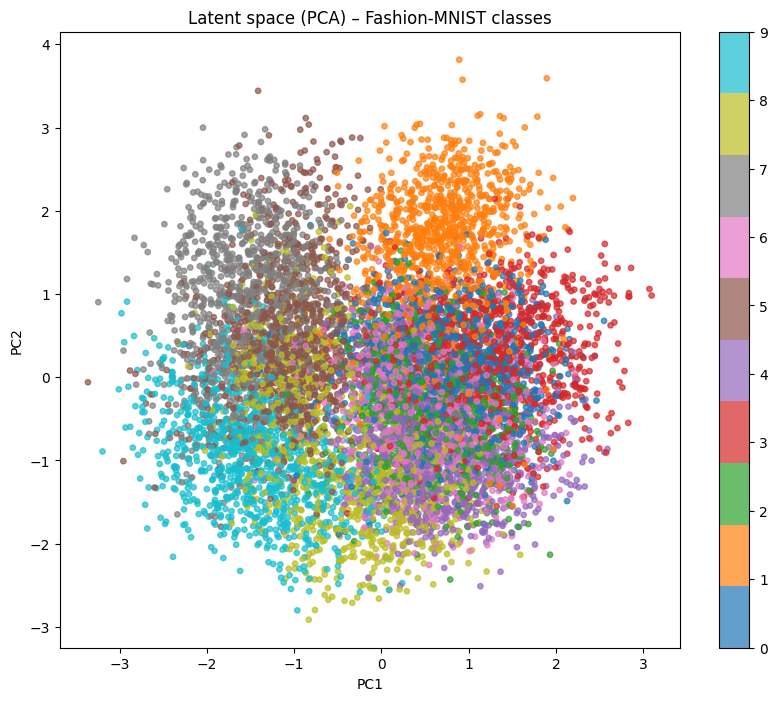

In [ ]:
# PCA to 2D
pca = PCA(n_components=2)
z_pca = pca.fit_transform(z_all)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(z_pca[:, 0], z_pca[:, 1], c=y_all, cmap="tab10", alpha=0.7, s=15)
plt.colorbar(scatter, ticks=range(10))
plt.title("Latent space (PCA) – Fashion‑MNIST classes")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

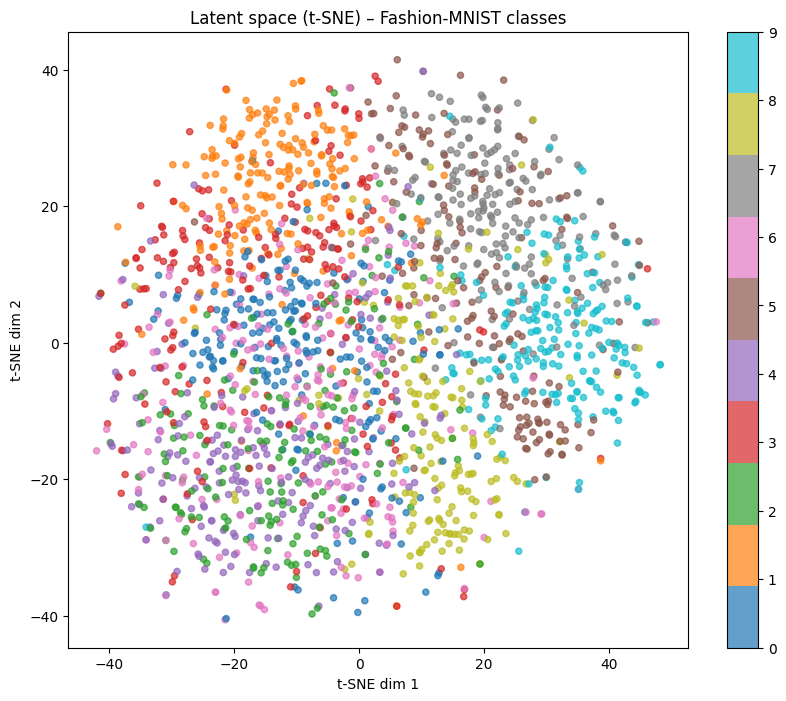

In [ ]:
# t‑SNE (only on a subset if dataset is large)
n_vis = 2000
idx = np.random.choice(len(z_all), n_vis, replace=False)
z_sub = z_all[idx]
y_sub = y_all[idx]

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
z_tsne = tsne.fit_transform(z_sub)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(z_tsne[:, 0], z_tsne[:, 1], c=y_sub, cmap="tab10", alpha=0.7, s=20)
plt.colorbar(scatter, ticks=range(10))
plt.title("Latent space (t‑SNE) – Fashion‑MNIST classes")
plt.xlabel("t‑SNE dim 1")
plt.ylabel("t‑SNE dim 2")
plt.show()

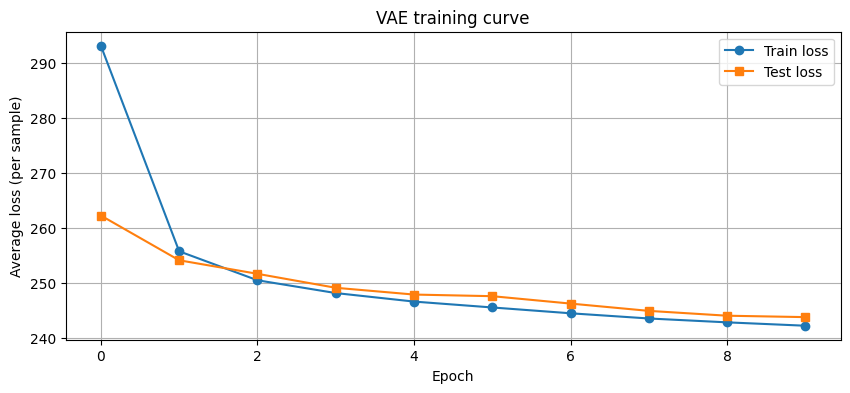

In [ ]:
# ploting loss
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train loss", marker="o")
plt.plot(test_losses,  label="Test loss",  marker="s")
plt.xlabel("Epoch")
plt.ylabel("Average loss (per sample)")
plt.title("VAE training curve")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# hyperparameters experiment
import pandas as pd

configs = [
    dict(hidden_dim=128, latent_dim=10, beta=0.5, lr=1e-3),
    dict(hidden_dim=128, latent_dim=20, beta=0.5, lr=1e-3),
    dict(hidden_dim=256, latent_dim=20, beta=1.0, lr=1e-3),
    dict(hidden_dim=256, latent_dim=32, beta=1.0, lr=5e-4),
]

results = []

for i, cfg in enumerate(configs):
    print(f"\n=== Experiment {i+1} ===")
    print(f"Config: {cfg}")

    # Build model
    model = VAE(
        input_dim=784,
        hidden_dim=cfg["hidden_dim"],
        latent_dim=cfg["latent_dim"]
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=cfg["lr"])

    train_loss_final = 0.0
    for epoch in range(5):  # short run for demo
        model.train()
        epoch_loss = 0.0
        n_samples = 0
        for x, _ in train_loader:
            x = x.to(device)
            optimizer.zero_grad()
            x_recon, mu, logvar = model(x)
            loss, _, _ = vae_loss(x, x_recon, mu, logvar, beta=cfg["beta"])
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_samples += x.size(0)
        avg_loss = epoch_loss / n_samples
        if epoch == 4:
            train_loss_final = avg_loss

    # Store config + final loss
    cfg["final_train_loss"] = train_loss_final
    results.append(cfg)

# Convert to DataFrame
df_results = pd.DataFrame(results)
print(df_results)


=== Experiment 1 ===
Config: {'hidden_dim': 128, 'latent_dim': 10, 'beta': 0.5, 'lr': 0.001}

=== Experiment 2 ===
Config: {'hidden_dim': 128, 'latent_dim': 20, 'beta': 0.5, 'lr': 0.001}

=== Experiment 3 ===
Config: {'hidden_dim': 256, 'latent_dim': 20, 'beta': 1.0, 'lr': 0.001}

=== Experiment 4 ===
Config: {'hidden_dim': 256, 'latent_dim': 32, 'beta': 1.0, 'lr': 0.0005}
   hidden_dim  latent_dim  beta      lr  final_train_loss
0         128          10   0.5  0.0010        241.284028
1         128          20   0.5  0.0010        241.803868
2         256          20   1.0  0.0010        245.811107
3         256          32   1.0  0.0005        250.132066


## Experiments

In this section, multiple experiments were performed to study how different hyperparameters affect the behavior and performance of the Variational Autoencoder (VAE).

### Hyperparameter Variations

The following parameters were changed during experimentation:

- `hidden_dim`: 128 vs 256  
  - Controls the capacity of the neural network (number of units in hidden layers).

- `latent_dim`: 10, 20, 32  
  - Controls the size of the compressed latent representation.

- `beta`: 0.5 vs 1.0  
  - Controls the strength of KL divergence regularization.

- `learning rate (lr)`: 1e-3 vs 5e-4  
  - Controls how quickly the optimizer updates the model parameters.

### Observations

- Smaller latent dimensions such as 10 resulted in higher reconstruction loss because the model had less capacity to store information.

- Increasing the hidden dimension and latent dimension generally improved reconstruction quality and reduced the final training loss, although training became slower due to the larger number of parameters.

- Lower `beta` values focused more on reconstruction quality, while higher `beta` values created a more regularized and structured latent space.

- Higher learning rates converged faster but sometimes caused unstable training, whereas lower learning rates produced smoother convergence.

These experiments helped demonstrate the trade‑off between reconstruction quality, latent space regularization, and model complexity.

## Results

After training the model and running the experiments, the following results were obtained:

### Reconstruction Results

The VAE successfully reconstructed Fashion‑MNIST images with reasonable quality. Some reconstructed images appeared slightly blurry, which is common in probabilistic generative models that optimize an average‑case objective.

### Generated Samples

By sampling random vectors from the latent space, the model generated new fashion‑style images that closely resembled the training dataset, showing that the model has learned meaningful features of fashion items.

### Latent Space Visualization

- **PCA visualization:** Showed partial separation between different fashion categories, with some classes overlapping and others forming distinct clusters.  
- **t‑SNE visualization:** Produced clearer local clusters, where nearby latent vectors often belonged to the same or similar classes, indicating that the latent space learned meaningful semantic structure.

### Training Curves

Both training and testing losses decreased steadily over epochs. The relatively small gap between train and test loss indicated that the model was not heavily overfitting under the chosen hyperparameter settings.

### Hyperparameter Experiment Results

The experiment table generated in the final code cell showed how different hyperparameter combinations affected the final training loss and overall model behavior. In general:
- Higher model capacity (`hidden_dim`, `latent_dim`) reduced loss.  
- Higher `beta` increased regularization and latent structure.  
- Lower `lr` gave smoother convergence.

## Analysis and Discussion

### What Worked Well

- The VAE trained successfully using the Adam optimizer and achieved stable convergence within 10 epochs.  
- The model was able to generate realistic fashion‑style images from randomly sampled latent vectors, demonstrating effective generative capability.  
- PCA and t‑SNE visualizations showed that the latent space learned meaningful representations of different fashion categories, even though the latent dimension was relatively small.

### Limitations and Challenges

- Some reconstructed images appeared blurry because VAEs optimize an average‑case probabilistic objective rather than focusing on sharp image details (this is a known limitation compared to models like GANs).  
- High `beta` values improved latent regularization but reduced reconstruction quality, clearly showing the trade‑off between structure and accuracy.  
- Very small latent dimensions caused underfitting because the model could not store enough information to accurately represent the data.

### Bias‑Variance and Overfitting

- The small difference between training and testing loss suggested that the model was reasonably well‑regularized.  
- Increasing model complexity (e.g., larger `hidden_dim` or `latent_dim`) without careful tuning of `beta` or learning rate could increase overfitting.  
- A larger `beta` value reduced variance by constraining the latent space, but this also increased reconstruction bias.

### Possible Improvements

Future improvements for this project could include:

- Implementing a **beta‑VAE** to encourage more disentangled latent representations.  
- Using **convolutional layers** instead of fully connected layers to better capture spatial image structure.  
- Training for more epochs with **learning rate scheduling** and early stopping to achieve better performance.  
- Experimenting with more advanced latent structures (e.g., hierarchical VAEs or normalizing flows).

## Real‑World Applications and Limitations

### Real‑World Applications of VAEs

- **Image generation:** VAEs can generate new images such as fashion items, artwork, faces, and synthetic datasets, which is useful for data augmentation and creative design.  
- **Image denoising and reconstruction:** VAEs can reconstruct clean images from noisy or corrupted inputs, which is useful in medical imaging and computer vision.  
- **Data compression and dimensionality reduction:** VAEs can compress high‑dimensional data (like images) into compact latent codes and reconstruct them later, enabling efficient storage and retrieval.  
- **Anomaly detection:** By analyzing reconstruction errors, VAEs can detect unusual or anomalous data points, which is useful in fraud detection, medical diagnosis, and industrial monitoring.  
- **Drug discovery and bioinformatics:** VAEs can generate or learn representations of molecular structures or protein sequences, helping explore chemical spaces for potential drugs.

### Limitations of VAEs

- Generated outputs are often **blurrier** compared to models like GANs, because VAEs optimize an average‑case probabilistic objective.  
- Hyperparameter tuning (especially `beta`, KL weight, and architecture) can be **sensitive and difficult**, requiring careful experimentation.  
- Latent variables are **not always clearly interpretable** without additional constraints or modifications (e.g., beta‑VAE, factor‑VAE).  
- Training is **computationally more expensive** than standard autoencoders due to the probabilistic modeling and reparameterization trick.

Overall, this assignment provided practical exposure to **generative modeling**, **latent representation learning**, and modern deep‑learning techniques used in current AI research.

## Conclusion

- The Variational Autoencoder successfully learned a compressed probabilistic representation of Fashion‑MNIST images.  
- The trained model reconstructed images effectively and generated new fashion‑style samples from the learned latent space.  
- PCA and t‑SNE visualizations demonstrated meaningful clustering behavior within the learned latent representations.  
- Hyperparameter experiments highlighted the trade‑offs between:
  - reconstruction quality,  
  - regularization strength (`beta`),  
  - and model capacity (`hidden_dim`, `latent_dim`).  
- Although VAEs have limitations such as blurry outputs and sensitive hyperparameter tuning, they remain powerful generative models for representation learning and synthetic data generation.  
- This assignment provided hands‑on understanding of **generative AI concepts** and their practical applications in modern machine learning systems.